In [8]:
"""
Workflow equivalent of:
    temp/models/TVB/TVB_1st_step_marmoset/1_TVB_First_steps.ipynb

One workflow is built and executed three times (120 s each), reconfiguring nodes
between runs. All simulations record TemporalAverage + BOLD and save both to file.

  Sim 1 — Resting state (G2dOscillator a=1.74, HeunStochastic, Scaling, no stimulus)
  Sim 2 — Stimulus response (a=0.5, HeunDeterministic, Linear, PulseTrain every 10 s)
  Sim 3 — BOLD demonstration (same as Sim 2, PulseTrain 2 pulses at 5 s and 65 s)

Output files (./results/):
  sim1_temporal_average.npz, sim1_bold.npz
  sim2_temporal_average.npz, sim2_bold.npz
  sim3_temporal_average.npz, sim3_bold.npz
"""

'\nWorkflow equivalent of:\n    temp/models/TVB/TVB_1st_step_marmoset/1_TVB_First_steps.ipynb\n\nOne workflow is built and executed three times (120 s each), reconfiguring nodes\nbetween runs. All simulations record TemporalAverage + BOLD and save both to file.\n\n  Sim 1 — Resting state (G2dOscillator a=1.74, HeunStochastic, Scaling, no stimulus)\n  Sim 2 — Stimulus response (a=0.5, HeunDeterministic, Linear, PulseTrain every 10 s)\n  Sim 3 — BOLD demonstration (same as Sim 2, PulseTrain 2 pulses at 5 s and 65 s)\n\nOutput files (./results/):\n  sim1_temporal_average.npz, sim1_bold.npz\n  sim2_temporal_average.npz, sim2_bold.npz\n  sim3_temporal_average.npz, sim3_bold.npz\n'

In [9]:
import os

try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.getcwd()  # Jupyter: CWD is the sandbox directory

CONNECTIVITY_FILE = os.path.abspath(
    os.path.join(
        _HERE,
        "../../../../temp/models/TVB/TVB_1st_step_marmoset/dataset/connectivity_marmoset.zip",
    )
)

from neuroworkflow import WorkflowBuilder
from neuroworkflow.nodes.network.TVBConnectivitySetUpNode import TVBConnectivitySetUpNode
from neuroworkflow.nodes.sandbox.TVBModelNodeV2 import TVBModelNodeV2
from neuroworkflow.nodes.sandbox.TVBCouplingNodeV2 import TVBCouplingNodeV2
from neuroworkflow.nodes.sandbox.TVBIntegratorNodeV2 import TVBIntegratorNodeV2
from neuroworkflow.nodes.sandbox.TVBMonitorNodeV2 import TVBMonitorNodeV2
from neuroworkflow.nodes.sandbox.TVBSimulatorNodeV2 import TVBSimulatorNodeV2
from neuroworkflow.nodes.sandbox.TVBStimuliRegionNodeV2 import TVBStimuliRegionNodeV2
from neuroworkflow.nodes.sandbox.TVBTimeSeriesPlotNodeV2 import TVBTimeSeriesPlotNodeV2


In [10]:
# ── Instantiate nodes ──────────────────────────────────────────────────────────

conn       = TVBConnectivitySetUpNode("Connectivity")
model      = TVBModelNodeV2("Model")
coupling   = TVBCouplingNodeV2("Coupling")
integrator = TVBIntegratorNodeV2("Integrator")
monitor    = TVBMonitorNodeV2("Monitor")
monitor2   = TVBMonitorNodeV2("Monitor2")
stimulus   = TVBStimuliRegionNodeV2("Stimulus")
sim        = TVBSimulatorNodeV2("Simulator")
plot       = TVBTimeSeriesPlotNodeV2("Plot")
plot2      = TVBTimeSeriesPlotNodeV2("Plot2")

conn.configure(connectivity_file=CONNECTIVITY_FILE)


In [11]:
# ── Build topology (shared across all simulations) ─────────────────────────────

wf = WorkflowBuilder("TVB_Marmoset")

wf.add_node(conn)
wf.add_node(model)
wf.add_node(coupling)
wf.add_node(integrator)
wf.add_node(monitor)
wf.add_node(monitor2)
wf.add_node(stimulus)
wf.add_node(sim)
wf.add_node(plot)
wf.add_node(plot2)

wf.connect("Connectivity", "tvb_connectivity", "Model",      "tvb_connectivity")
wf.connect("Connectivity", "tvb_connectivity", "Simulator",  "tvb_connectivity")
wf.connect("Connectivity", "tvb_connectivity", "Stimulus",   "tvb_connectivity")
wf.connect("Connectivity", "tvb_connectivity", "Plot",       "tvb_connectivity")
wf.connect("Connectivity", "tvb_connectivity", "Plot2",      "tvb_connectivity")
wf.connect("Model",        "tvb_model",        "Simulator",  "tvb_model")
wf.connect("Coupling",     "tvb_coupling",     "Simulator",  "tvb_coupling")
wf.connect("Integrator",   "tvb_integrator",   "Simulator",  "tvb_integrator")
wf.connect("Monitor",      "tvb_monitor",      "Simulator",  "tvb_monitor")
wf.connect("Monitor2",     "tvb_monitor",      "Simulator",  "tvb_monitor_2")
wf.connect("Stimulus",     "tvb_stimulus",     "Simulator",  "tvb_stimulus")
wf.connect("Simulator",    "tvb_simdata",      "Plot",       "tvb_simdata")
wf.connect("Simulator",    "tvb_simtime",      "Plot",       "tvb_simtime")
wf.connect("Simulator",    "tvb_simdata_2",    "Plot2",      "tvb_simdata")
wf.connect("Simulator",    "tvb_simtime_2",    "Plot2",      "tvb_simtime")

workflow = wf.build()


SIM 1: Resting state
Workflow: TVB_Marmoset
Nodes:
  Connectivity
  Model
  Coupling
  Integrator
  Monitor
  Monitor2
  Stimulus
  Simulator
  Plot
  Plot2
Connections:
  Connectivity.tvb_connectivity -> Model.tvb_connectivity
  Connectivity.tvb_connectivity -> Simulator.tvb_connectivity
  Connectivity.tvb_connectivity -> Stimulus.tvb_connectivity
  Connectivity.tvb_connectivity -> Plot.tvb_connectivity
  Connectivity.tvb_connectivity -> Plot2.tvb_connectivity
  Model.tvb_model -> Simulator.tvb_model
  Coupling.tvb_coupling -> Simulator.tvb_coupling
  Integrator.tvb_integrator -> Simulator.tvb_integrator
  Monitor.tvb_monitor -> Simulator.tvb_monitor
  Monitor2.tvb_monitor -> Simulator.tvb_monitor_2
  Stimulus.tvb_stimulus -> Simulator.tvb_stimulus
  Simulator.tvb_simdata -> Plot.tvb_simdata
  Simulator.tvb_simtime -> Plot.tvb_simtime
  Simulator.tvb_simdata_2 -> Plot2.tvb_simdata
  Simulator.tvb_simtime_2 -> Plot2.tvb_simtime

Executing...
Executing node: Monitor2
Executing node: Mon

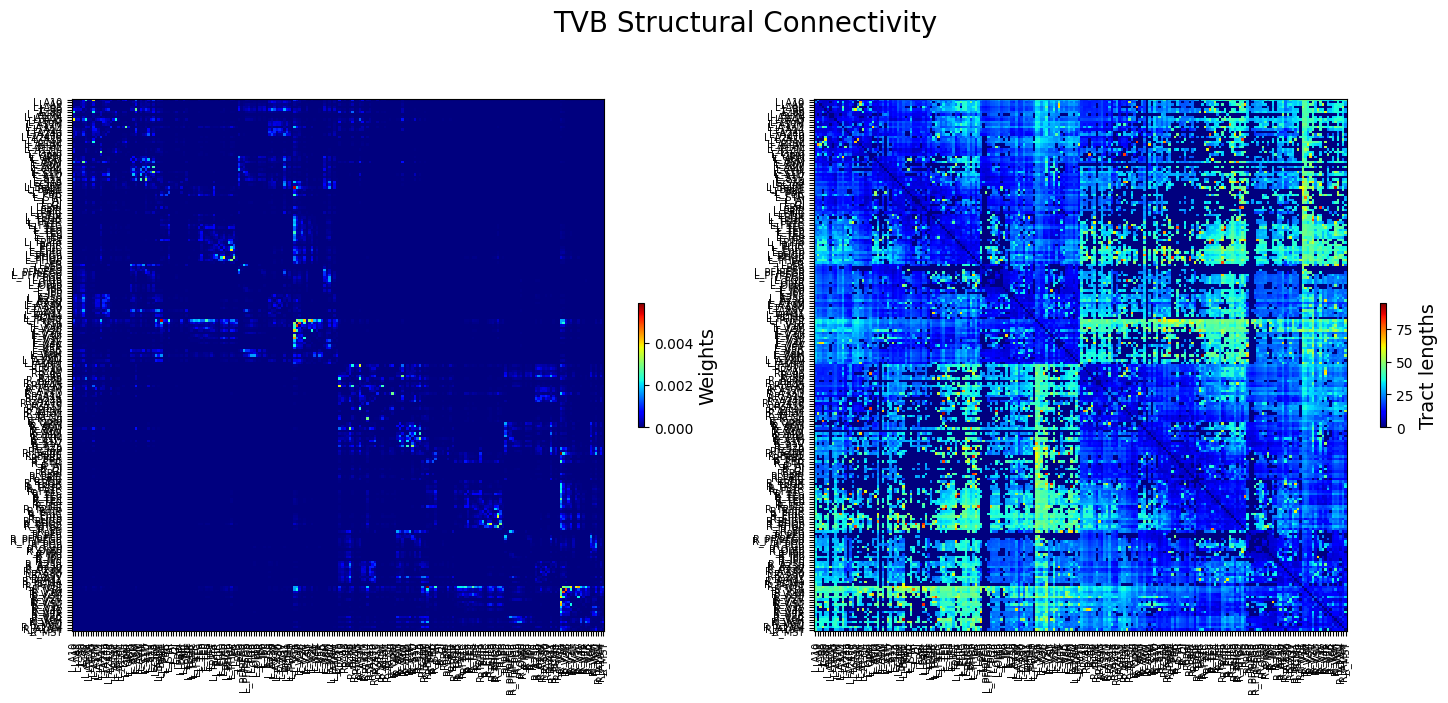

Executing node: Stimulus
Executing node: Model
Executing node: Simulator
[Simulator] simulation completed in 15.539s
Executing node: Plot2
[Plot2] Saved simulation data to: /Users/carlosengutierrez/Downloads/neuro-workflow/src/neuroworkflow/nodes/sandbox/results/sim1_bold.npz


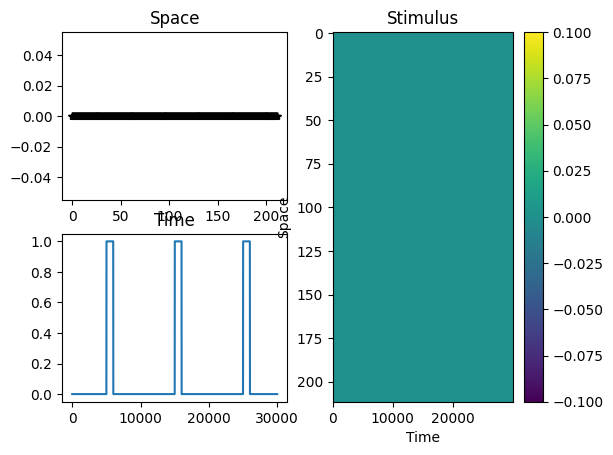

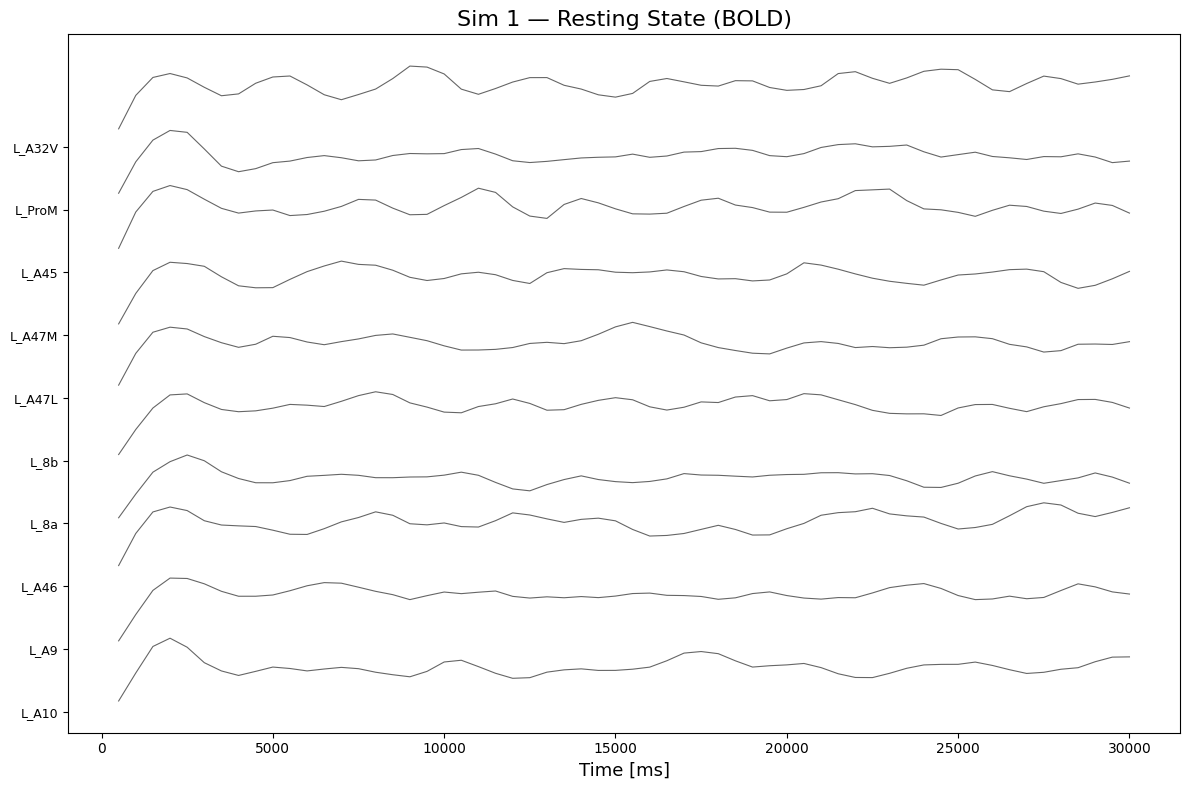

Executing node: Plot
[Plot] Saved simulation data to: /Users/carlosengutierrez/Downloads/neuro-workflow/src/neuroworkflow/nodes/sandbox/results/sim1_temporal_average.npz


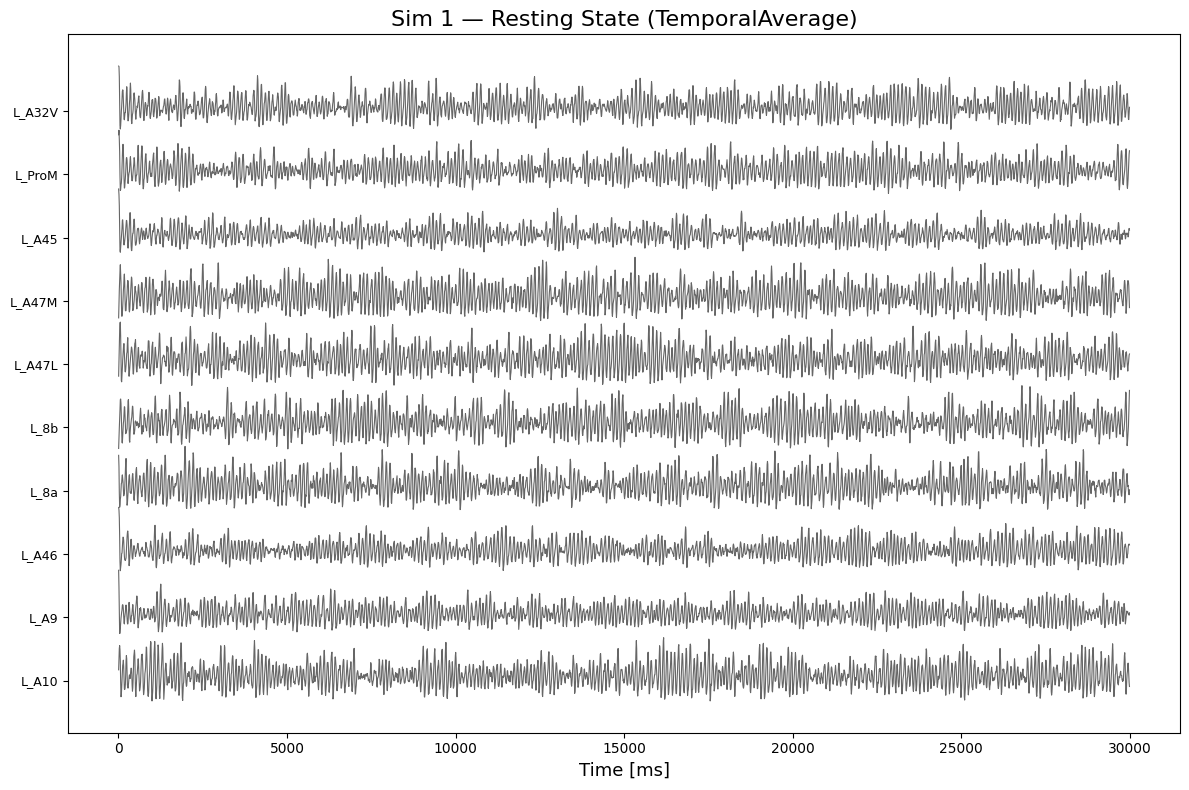

Sim 1 done.



In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# SIM 1 — Resting state (30 s, no stimulus)
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("SIM 1: Resting state")
print("=" * 60)

model.configure(model_type="Generic2dOscillator", model_params={"a": 1.74}, region_params={})
coupling.configure(coupling_type="Scaling", a=0.0075)
integrator.configure(integrator_type="HeunStochastic", dt=0.5, nsig=[0.001, 0.0])
monitor.configure(monitor_type="TemporalAverage", period=10.0)
monitor2.configure(monitor_type="Bold", period=500.0)
stimulus.configure(
    region_indices=[0, 7, 13, 33, 42],
    weights=[0.0, 0.0, 0.0, 0.0, 0.0],
    temporal_equation="PulseTrain",
    equation_params={"T": 10000.0, "tau": 1000.0, "amp": 1.0, "onset": 5000.0},
    simulation_length=30000.0,
)
sim.configure(simulation_length=30000.0)
plot.configure(
    n_regions=10, state_variable_index=0, normalize=True,
    title="Sim 1 — Resting State (TemporalAverage)",
    save_to_file=True, output_path="./results/sim1_temporal_average.npz",
)
plot2.configure(
    n_regions=10, state_variable_index=0, normalize=True,
    title="Sim 1 — Resting State (BOLD)",
    save_to_file=True, output_path="./results/sim1_bold.npz",
)

print(workflow)
print("\nExecuting...")
success = workflow.execute()
print("Sim 1 done.\n" if success else "Sim 1 FAILED.\n")


SIM 2: Stimulus response

Executing...
Executing node: Monitor2
Executing node: Monitor
Executing node: Integrator
Executing node: Coupling
Executing node: Connectivity
[Connectivity] Using connectivity file from parameter: /Users/carlosengutierrez/Downloads/neuro-workflow/temp/models/TVB/TVB_1st_step_marmoset/dataset/connectivity_marmoset.zip
2026-04-29 07:24:42,508 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


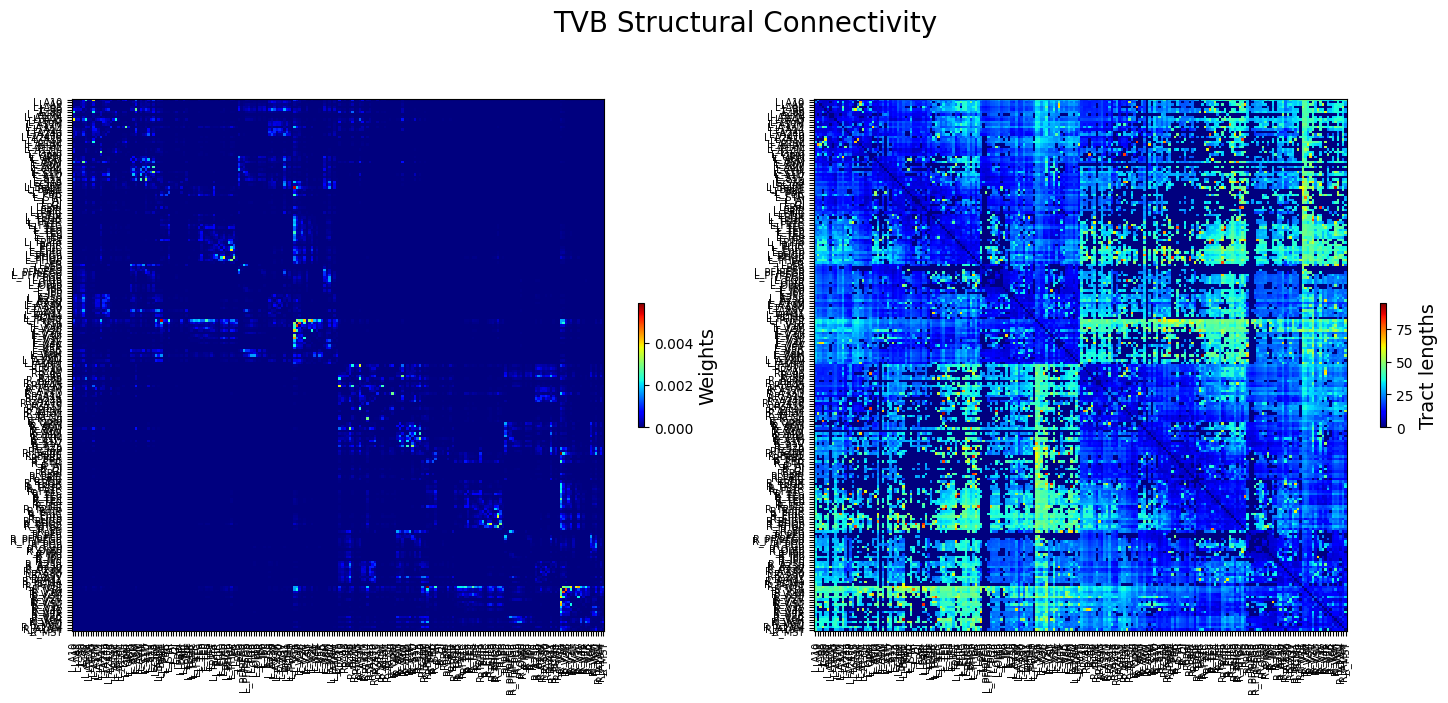

Executing node: Stimulus
Executing node: Model
Executing node: Simulator
2026-04-29 07:24:43,374 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
[Simulator] simulation completed in 30.550s
Executing node: Plot2
[Plot2] Saved simulation data to: /Users/carlosengutierrez/Downloads/neuro-workflow/src/neuroworkflow/nodes/sandbox/results/sim2_bold.npz


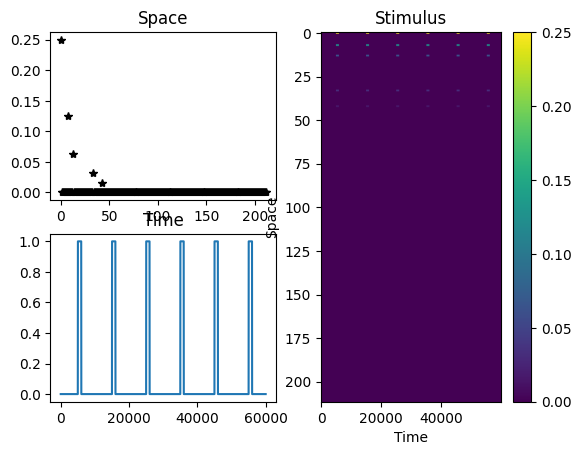

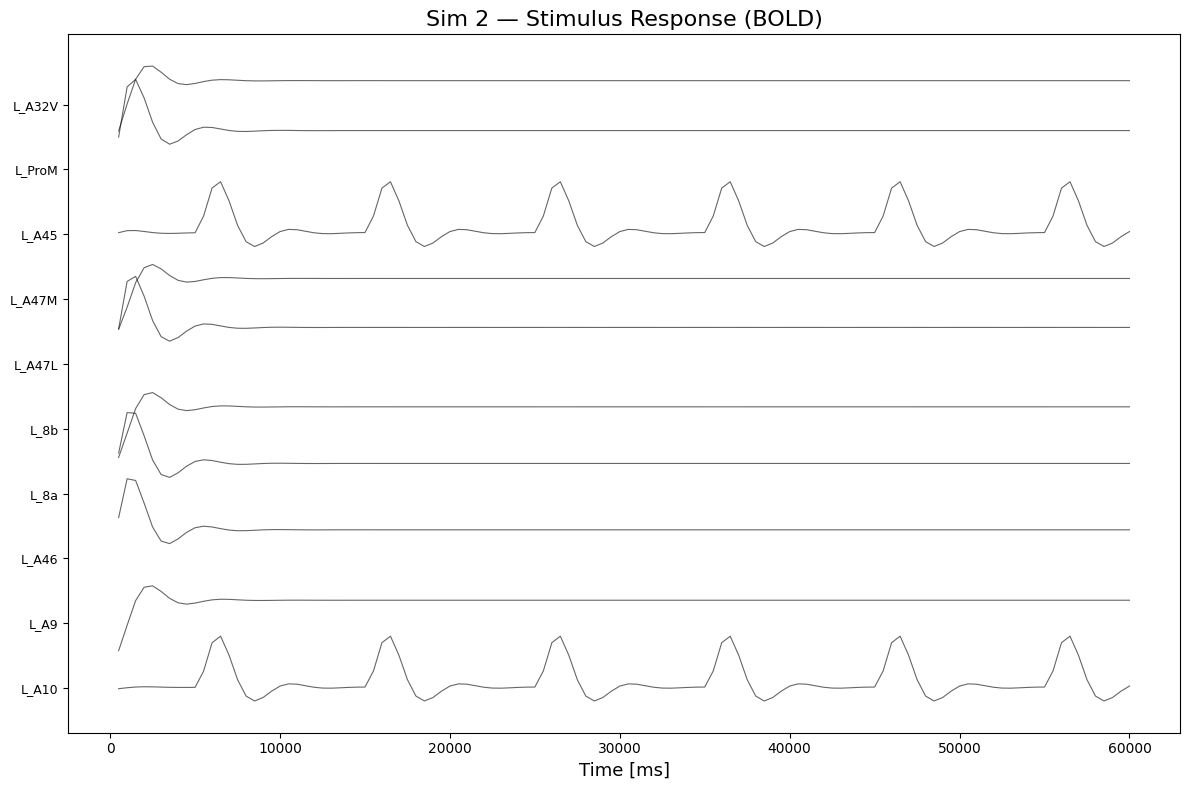

Executing node: Plot
[Plot] Saved simulation data to: /Users/carlosengutierrez/Downloads/neuro-workflow/src/neuroworkflow/nodes/sandbox/results/sim2_temporal_average.npz


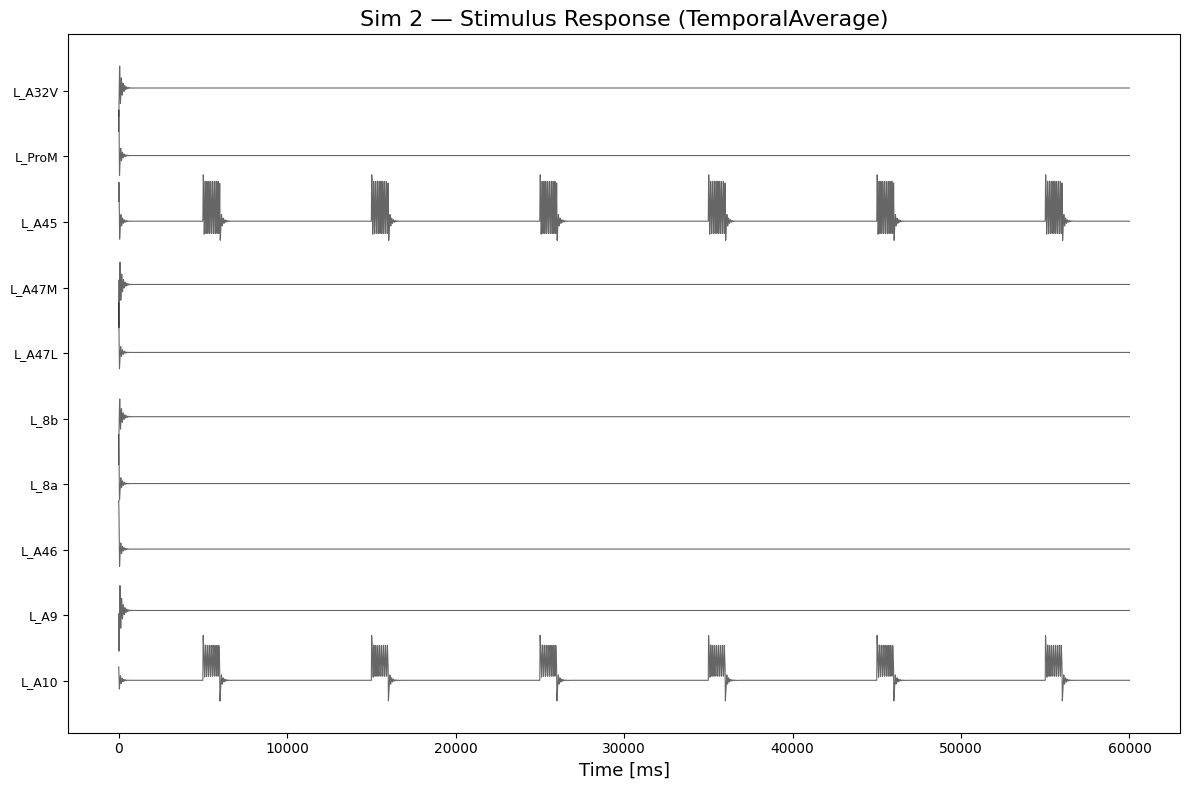

Sim 2 done.



In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# SIM 2 — Stimulus response (60 s, PulseTrain every 10 s)
# Changes from Sim 1: model a, coupling, integrator, monitor period,
#                     stimulus weights, simulation length
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("SIM 2: Stimulus response")
print("=" * 60)

model.configure(model_type="Generic2dOscillator", model_params={"a": 0.5}, region_params={})
coupling.configure(coupling_type="Linear", a=0.0126, b=0.0)
integrator.configure(integrator_type="HeunDeterministic", dt=0.5, nsig=[0.0, 0.0])
monitor.configure(monitor_type="TemporalAverage", period=1.0)
stimulus.configure(
    region_indices=[0, 7, 13, 33, 42],
    weights=[0.25, 0.125, 0.0625, 0.03125, 0.015625],  # ← only change vs Sim 1
    temporal_equation="PulseTrain",
    equation_params={"T": 10000.0, "tau": 1000.0, "amp": 1.0, "onset": 5000.0},
    simulation_length=60000.0,
)
sim.configure(simulation_length=60000.0)
plot.configure(
    n_regions=10, state_variable_index=0, normalize=True,
    title="Sim 2 — Stimulus Response (TemporalAverage)",
    save_to_file=True, output_path="./results/sim2_temporal_average.npz",
)
plot2.configure(
    n_regions=10, state_variable_index=0, normalize=True,
    title="Sim 2 — Stimulus Response (BOLD)",
    save_to_file=True, output_path="./results/sim2_bold.npz",
)

print("\nExecuting...")
success = workflow.execute()
print("Sim 2 done.\n" if success else "Sim 2 FAILED.\n")



SIM 3: BOLD demonstration

Executing...
Executing node: Monitor2
Executing node: Monitor
Executing node: Integrator
Executing node: Coupling
Executing node: Connectivity
[Connectivity] Using connectivity file from parameter: /Users/carlosengutierrez/Downloads/neuro-workflow/temp/models/TVB/TVB_1st_step_marmoset/dataset/connectivity_marmoset.zip
2026-04-29 07:25:14,870 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


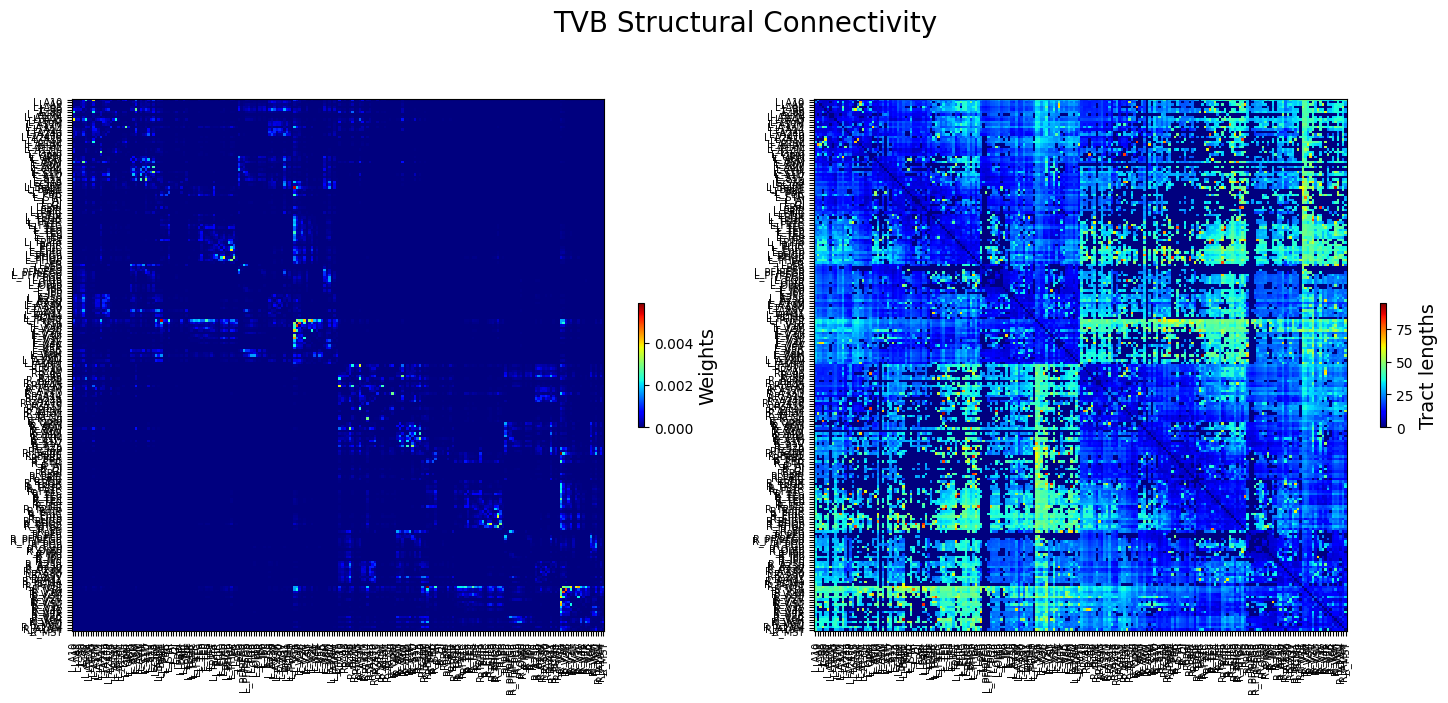

Executing node: Stimulus
Executing node: Model
Executing node: Simulator
2026-04-29 07:25:15,770 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
[Simulator] simulation completed in 30.345s
Executing node: Plot2
[Plot2] Saved simulation data to: /Users/carlosengutierrez/Downloads/neuro-workflow/src/neuroworkflow/nodes/sandbox/results/sim3_bold.npz


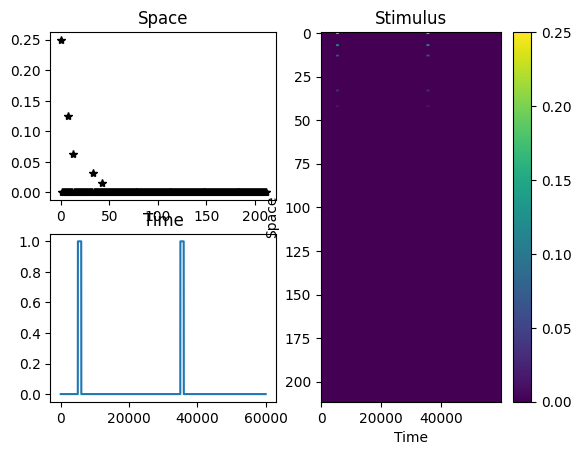

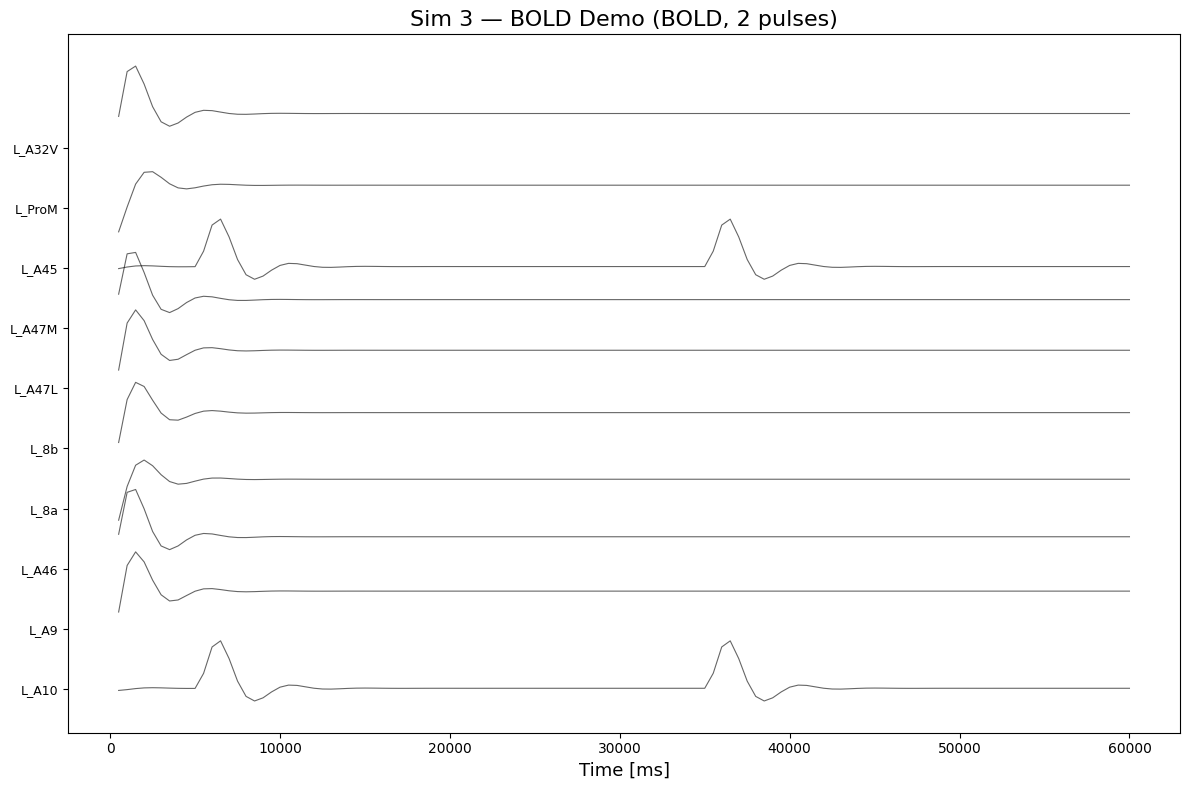

Executing node: Plot
[Plot] Saved simulation data to: /Users/carlosengutierrez/Downloads/neuro-workflow/src/neuroworkflow/nodes/sandbox/results/sim3_temporal_average.npz


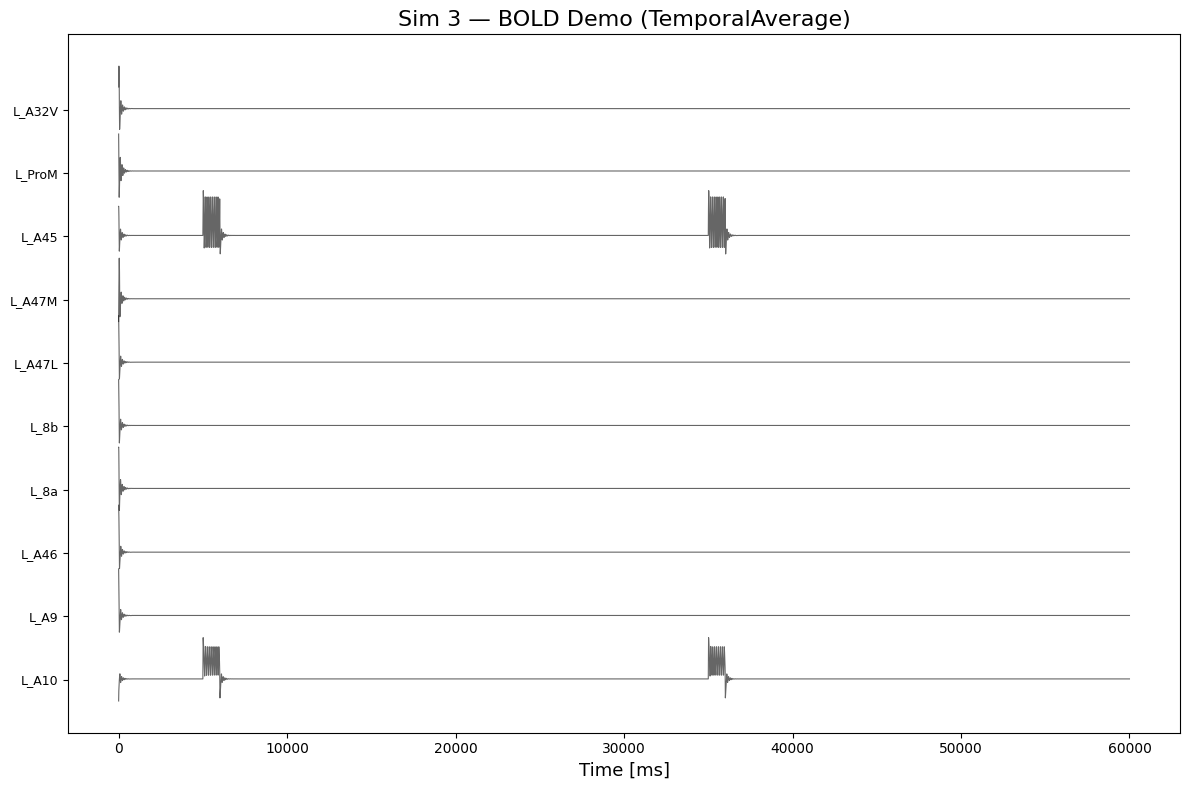

Sim 3 done.



In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# SIM 3 — BOLD demonstration (60 s, 2 pulses at 5 s and 35 s)
# Changes from Sim 2: stimulus T only (10 000 ms → 30 000 ms)
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("SIM 3: BOLD demonstration")
print("=" * 60)

stimulus.configure(
    region_indices=[0, 7, 13, 33, 42],
    weights=[0.25, 0.125, 0.0625, 0.03125, 0.015625],
    temporal_equation="PulseTrain",
    equation_params={"T": 30000.0, "tau": 1000.0, "amp": 1.0, "onset": 5000.0},  # ← only change vs Sim 2
    simulation_length=60000.0,
)
plot.configure(
    n_regions=10, state_variable_index=0, normalize=True,
    title="Sim 3 — BOLD Demo (TemporalAverage)",
    save_to_file=True, output_path="./results/sim3_temporal_average.npz",
)
plot2.configure(
    n_regions=10, state_variable_index=0, normalize=True,
    title="Sim 3 — BOLD Demo (BOLD, 2 pulses)",
    save_to_file=True, output_path="./results/sim3_bold.npz",
)

print("\nExecuting...")
success = workflow.execute()
print("Sim 3 done.\n" if success else "Sim 3 FAILED.\n")
